In [ ]:
import rasterio
from pathlib import Path

TILE_ID = "tile_1041_2429"  # fill in actual tile_id

tile_dir = Path(f"../data/test_tiles/{TILE_ID}")  # fill in actual tile_id

tif_paths = sorted(tile_dir.glob("*/*.tif"))

print(f"{'file':40s} {'crs':25s} {'shape':12s} {'transform'}")
ref = None
for p in tif_paths:
    with rasterio.open(p) as src:
        info = (src.crs, (src.height, src.width), src.transform)
        rel = p.relative_to(tile_dir)
        print(f"{str(rel):40s} {str(info[0]):25s} {str(info[1]):12s} {info[2]}")
        if ref is None:
            ref = info
        else:
            same_crs = info[0] == ref[0]
            same_shape = info[1] == ref[1]
            same_transform = info[2].almost_equals(ref[2], precision=6)
            if not (same_crs and same_shape and same_transform):
                print(f"  !! MISALIGNED vs {tif_paths[0].relative_to(tile_dir)}: "
                      f"crs={same_crs} shape={same_shape} transform={same_transform}")

file                                     crs                       shape        transform
composites/s1s2_2017.tif                 EPSG:6933                 (256, 256)   | 10.00, 0.00, 156160.00|
| 0.00,-10.00, 5240320.00|
| 0.00, 0.00, 1.00|
composites/s1s2_2024.tif                 EPSG:6933                 (256, 256)   | 10.00, 0.00, 156160.00|
| 0.00,-10.00, 5240320.00|
| 0.00, 0.00, 1.00|
embeddings/aee_2017.tif                  EPSG:6933                 (256, 256)   | 10.00, 0.00, 156160.00|
| 0.00,-10.00, 5240320.00|
| 0.00, 0.00, 1.00|
embeddings/aee_2024.tif                  EPSG:6933                 (256, 256)   | 10.00, 0.00, 156160.00|
| 0.00,-10.00, 5240320.00|
| 0.00, 0.00, 1.00|
embeddings/tessera_2017.tif              EPSG:6933                 (256, 256)   | 10.00, 0.00, 156160.00|
| 0.00,-10.00, 5240320.00|
| 0.00, 0.00, 1.00|
embeddings/tessera_2024.tif              EPSG:6933                 (256, 256)   | 10.00, 0.00, 156160.00|
| 0.00,-10.00, 5240320.00|
| 0.00, 0.00

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import numpy as np
import rasterio
from matplotlib.colors import Normalize
from skimage.feature import graycomatrix, graycoprops
from scipy.ndimage import zoom

years = list(range(2017, 2025))  # 2017-2024 inclusive


# Matches current composites/s1s2_<year>.tif band order (13 bands)
BAND_INDEX = {
    "B2": 1, "B3": 2, "B4": 3, "B8": 4,
    "B5": 5, "B6": 6, "B7": 7, "B8A": 8, "B11": 9, "B12": 10,
    "VV": 11, "VH": 12, "VVVH": 13,
}


def read(path, bands=None):
    with rasterio.open(path) as src:
        arr = src.read(bands) if bands else src.read()
        return arr, src.bounds, src.transform


def stretch(arr, low=2, high=98):
    """Independent percentile stretch for visualisation only. Fits its own
    bounds from whatever array it's given -- fine for a one-off single
    image, but NOT used for TESSERA/AEE/index panels below, since fitting
    per-frame would make color meaning inconsistent across years."""
    out = np.empty_like(arr, dtype="float32")
    for b in range(arr.shape[-1]):
        lo, hi = np.nanpercentile(arr[..., b], [low, high])
        if hi == lo:
            out[..., b] = 0
        else:
            out[..., b] = np.clip((arr[..., b] - lo) / (hi - lo), 0, 1)
    return out


def fit_stretch_bounds(arrays, low=2, high=98):
    """Shared per-band percentile bounds across years for (H, W, C) arrays."""
    stacked = np.concatenate([a.reshape(-1, a.shape[-1]) for a in arrays], axis=0)
    bounds = []
    for b in range(stacked.shape[-1]):
        lo, hi = np.nanpercentile(stacked[:, b], [low, high])
        bounds.append((lo, hi))
    return bounds


def stretch_fixed(arr, bounds):
    out = np.empty_like(arr, dtype="float32")
    for b, (lo, hi) in enumerate(bounds):
        if hi == lo:
            out[..., b] = 0
        else:
            out[..., b] = np.clip((arr[..., b] - lo) / (hi - lo), 0, 1)
    return out


def fit_single_band_bounds(arrays, low=2, high=98):
    """Same idea as fit_stretch_bounds but for single-band (H, W) arrays
    (indices, texture maps) -- one shared (lo, hi) across all years."""
    stacked = np.concatenate([a.ravel() for a in arrays])
    valid = stacked[np.isfinite(stacked)]
    return np.nanpercentile(valid, [low, high])


def safe_ratio(numerator, denominator):
    denom = np.where(denominator == 0, np.nan, denominator)
    return numerator / denom


def glcm_texture_map(
    arr,
    win=5,
    levels=32,
    prop="contrast",
    distances=(1,),
    angles=(0, np.pi / 4, np.pi / 2, 3 * np.pi / 4),
):
    """
    Pixel-resolution GLCM texture following the SITS approach.

    A GLCM is calculated for a sliding odd-sized window centred on
    each output pixel. The resulting texture map has the same H x W
    resolution as the input.

    Based on the approach described in:
    https://e-sensing.github.io/sitsbook/dc_texture.html
    """
    if win < 3 or win % 2 == 0:
        raise ValueError("win must be an odd integer >= 3")

    h, w = arr.shape

    valid = np.isfinite(arr)
    if not valid.any():
        return np.full((h, w), np.nan, dtype=np.float32)

    # Quantise the input into grey levels, as required by GLCM.
    lo, hi = np.nanpercentile(arr[valid], [1, 99])
    scale = max(hi - lo, 1e-9)

    q = np.clip(
        ((arr - lo) / scale) * (levels - 1),
        0,
        levels - 1,
    )

    # Missing values cannot be represented directly in graycomatrix.
    q = np.nan_to_num(q, nan=0).astype(np.uint8)

    out = np.full((h, w), np.nan, dtype=np.float32)

    radius = win // 2

    for y in range(radius, h - radius):
        for x in range(radius, w - radius):

            window = q[
                y - radius:y + radius + 1,
                x - radius:x + radius + 1,
            ]

            glcm = graycomatrix(
                window,
                distances=list(distances),
                angles=list(angles),
                levels=levels,
                symmetric=True,
                normed=True,
            )

            out[y, x] = graycoprops(glcm, prop).mean()

    return out

slope, _, _ = read(tile_dir / "static" / "slope.tif", bands=[1])
protected, _, _ = read(tile_dir / "static" / "protected_area.tif", bands=[1])

gain_conf, _, _ = read(tile_dir / "labels" / "gain_confidence.tif", bands=[1])
gain_conf = gain_conf[0]
gain_conf_masked = np.ma.masked_where(np.isnan(gain_conf), gain_conf)
gain_norm = Normalize(vmin=50, vmax=100)

def fixed_stretch(arr, vmin=0, vmax=3000):
    return np.clip((arr - vmin) / (vmax - vmin), 0, 1)


def _db_stretch(band, vmin, vmax):
    return np.clip((band - vmin) / (vmax - vmin), 0, 1)


tess_raw, aee_raw = {}, {}
ndvi_raw, nbr_raw, ndmi_raw, rvi_raw, vv_texture_raw = {}, {}, {}, {}, {}

for year in years:
    tess, _, _ = read(tile_dir / "embeddings" / f"tessera_{year}.tif", bands=[1, 2, 3])
    tess_raw[year] = tess.transpose(1, 2, 0)

    aee, _, _ = read(tile_dir / "embeddings" / f"aee_{year}.tif", bands=[1, 2, 3])
    aee_raw[year] = aee.transpose(1, 2, 0)

    composite = tile_dir / "composites" / f"s1s2_{year}.tif"
    bands, _, _ = read(composite, bands=[
        BAND_INDEX["B4"], BAND_INDEX["B8"], BAND_INDEX["B11"], BAND_INDEX["B12"],
        BAND_INDEX["VV"], BAND_INDEX["VH"],
    ])
    b4, b8, b11, b12, vv, vh = bands[0], bands[1], bands[2], bands[3], bands[4], bands[5]

    ndvi_raw[year] = safe_ratio(b8 - b4, b8 + b4)
    nbr_raw[year] = safe_ratio(b8 - b12, b8 + b12)
    ndmi_raw[year] = safe_ratio(b8 - b11, b8 + b11)

    # RVI assumes linear power, not dB -- convert if your S1 export is in dB
    # (typical for S1_GRD after GEE default processing). If VV/VH are
    # already linear in your pipeline, drop the 10**(x/10) conversion.
    vv_lin = 10 ** (vv / 10.0)
    vh_lin = 10 ** (vh / 10.0)
    rvi_raw[year] = safe_ratio(4.0 * vh_lin, vv_lin + vh_lin)

    vv_texture_raw[year] = glcm_texture_map(vv, win=5, prop="contrast")

# Fit shared bounds once across years, same convention as tess/aee above
tess_bounds = fit_stretch_bounds(list(tess_raw.values()))
aee_bounds = fit_stretch_bounds(list(aee_raw.values()))
nbr_bounds = fit_single_band_bounds(list(nbr_raw.values()))
ndmi_bounds = fit_single_band_bounds(list(ndmi_raw.values()))
rvi_bounds = fit_single_band_bounds(list(rvi_raw.values()))
texture_bounds = fit_single_band_bounds(list(vv_texture_raw.values()))

frames = []
for year in years:
    composite = tile_dir / "composites" / f"s1s2_{year}.tif"

    s2, _, _ = read(composite, bands=[BAND_INDEX["B4"], BAND_INDEX["B3"], BAND_INDEX["B2"]])
    rgb = fixed_stretch(s2.transpose(1, 2, 0))

    s1, _, _ = read(composite, bands=[BAND_INDEX["VV"], BAND_INDEX["VH"]])
    vv, vh = s1[0], s1[1]
    s1_rgb = np.stack([
        _db_stretch(vv, -25, 0),
        _db_stretch(vh, -30, -5),
        _db_stretch(vv - vh, 0, 15),
    ], axis=-1)

    tess_rgb = stretch_fixed(tess_raw[year], tess_bounds)
    aee_rgb = stretch_fixed(aee_raw[year], aee_bounds)

    frames.append({
        "year": year,
        "rgb": rgb,
        "ndvi": ndvi_raw[year],
        "s1": s1_rgb,
        "tess": tess_rgb,
        "aee": aee_rgb,
        "nbr": nbr_raw[year],
        "ndmi": ndmi_raw[year],
        "rvi": rvi_raw[year],
        "texture": vv_texture_raw[year],
    })

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
title = fig.suptitle("")

im_rgb = axes[0, 0].imshow(frames[0]["rgb"]); axes[0, 0].set_title("Sentinel-2 RGB")
im_ndvi = axes[0, 1].imshow(frames[0]["ndvi"], cmap="RdYlGn", vmin=-1, vmax=1); axes[0, 1].set_title("NDVI")
im_s1 = axes[0, 2].imshow(frames[0]["s1"]); axes[0, 2].set_title("Sentinel-1 VV / VH / VV-VH")
im_tess = axes[0, 3].imshow(frames[0]["tess"]); axes[0, 3].set_title("TESSERA")

im_aee = axes[1, 0].imshow(frames[0]["aee"]); axes[1, 0].set_title("AEE")
im_nbr = axes[1, 1].imshow(frames[0]["nbr"], cmap="RdYlGn", vmin=nbr_bounds[0], vmax=nbr_bounds[1]); axes[1, 1].set_title("NBR")
im_ndmi = axes[1, 2].imshow(frames[0]["ndmi"], cmap="RdYlGn", vmin=ndmi_bounds[0], vmax=ndmi_bounds[1]); axes[1, 2].set_title("NDMI")
im_rvi = axes[1, 3].imshow(frames[0]["rvi"], cmap="viridis", vmin=rvi_bounds[0], vmax=rvi_bounds[1]); axes[1, 3].set_title("RVI (S1)")

axes[2, 0].imshow(slope[0], cmap="viridis", vmin=0, vmax=max(np.nanmax(slope), 1e-6)); axes[2, 0].set_title("Slope")
axes[2, 1].imshow(protected[0], cmap="Greens", vmin=0, vmax=1); axes[2, 1].set_title("Protected area")

overlay_rgb = axes[2, 2].imshow(frames[0]["rgb"])
overlay_gain = axes[2, 2].imshow(gain_conf_masked, cmap="plasma", norm=gain_norm, alpha=0.75)
axes[2, 2].set_title("Gain confidence")
cbar = fig.colorbar(overlay_gain, ax=axes[2, 2], fraction=0.046, pad=0.04)
cbar.set_label("Tree cover confidence (canopy cover %, year_end)")

im_texture = axes[2, 3].imshow(frames[0]["texture"], cmap="magma", vmin=texture_bounds[0], vmax=texture_bounds[1])
axes[2, 3].set_title("GLCM contrast (VV, blockwise)")

for ax in axes.flat:
    ax.axis("off")


def update(i):
    f = frames[i]
    title.set_text(f"{TILE_ID} — {f['year']}")

    im_rgb.set_data(f["rgb"])
    im_ndvi.set_data(f["ndvi"])
    im_s1.set_data(f["s1"])
    im_tess.set_data(f["tess"])
    im_aee.set_data(f["aee"])
    im_nbr.set_data(f["nbr"])
    im_ndmi.set_data(f["ndmi"])
    im_rvi.set_data(f["rvi"])
    im_texture.set_data(f["texture"])
    overlay_rgb.set_data(f["rgb"])

    return (title, im_rgb, im_ndvi, im_s1, im_tess, im_aee,
            im_nbr, im_ndmi, im_rvi, overlay_rgb, overlay_gain, im_texture)


anim = FuncAnimation(fig, update, frames=len(frames), interval=800, blit=False)
plt.close(fig)
HTML(anim.to_jshtml())

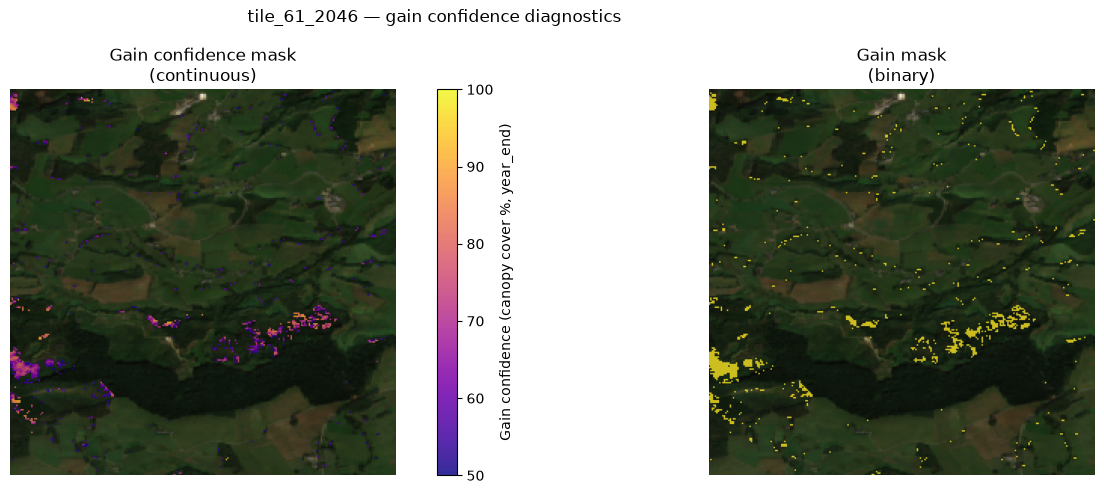

gain pixels: 1356
gain percentage of tile: 2.07%

Gain confidence:
  min:  50.196
  mean: 65.018
  max:  95.294


In [ ]:
import matplotlib.pyplot as plt
import numpy as np


# Continuous gain confidence
gain_conf, _, _ = read(
    tile_dir / "labels" / "gain_confidence.tif",
    bands=[1],
)
gain_conf = gain_conf[0]

# Binary version derived from confidence (NaN outside coverage, so
# isnan is the correct mask -- gain_conf > 0 happens to work too since
# every valid pixel is >50, but isnan says what's actually meant)
gain_valid = ~np.isnan(gain_conf)
gain_binary = gain_valid

comp_2024, _, _ = read(
    tile_dir / "composites" / "s1s2_2024.tif",
    bands=[3, 2, 1],
)

rgb_2024 = fixed_stretch(
    comp_2024.transpose(1, 2, 0)
)

fig2, axes2 = plt.subplots(
    1,
    2,
    figsize=(20, 5),
)

fig2.suptitle(
    f"{TILE_ID} — gain confidence diagnostics"
)

axes2[0].imshow(rgb_2024)

gain_masked = np.ma.masked_where(
    ~gain_valid,
    gain_conf,
)

# Fixed 50-100 scale -- matches the first animation cell, and matches
# gain_confidence.tif's real physical range (every validated pixel is
# canopy-cover % at year_end, which is always >TREE_THRESHOLD=50 by
# construction). Using np.nanmax(gain_conf) here instead would rescale
# each tile independently, making tiles visually incomparable and
# inconsistent with the other diagnostic cell.
im2 = axes2[0].imshow(
    gain_masked,
    cmap="plasma",
    vmin=50,
    vmax=100,
    alpha=0.85,
)

axes2[0].set_title(
    "Gain confidence mask\n(continuous)"
)

cbar = fig2.colorbar(
    im2,
    ax=axes2[0],
    fraction=0.046,
    pad=0.04,
)

cbar.set_label(
    "Gain confidence (canopy cover %, year_end)"
)

axes2[1].imshow(rgb_2024)

im3 = axes2[1].imshow(
    np.ma.masked_where(
        ~gain_binary,
        gain_binary,
    ),
    cmap="viridis",
    vmin=0,
    vmax=1,
    alpha=0.8,
)

axes2[1].set_title(
    "Gain mask\n(binary)"
)


for ax in axes2:
    ax.axis("off")


plt.tight_layout()
plt.show()

n_gain = int(gain_binary.sum())

print(
    f"gain pixels: {n_gain}"
)

print(
    f"gain percentage of tile: "
    f"{100*n_gain/gain_binary.size:.2f}%"
)


if n_gain > 0:
    gain_conf_values = gain_conf[gain_binary]

    print("\nGain confidence:")
    print(f"  min:  {np.nanmin(gain_conf_values):.3f}")
    print(f"  mean: {np.nanmean(gain_conf_values):.3f}")
    print(f"  max:  {np.nanmax(gain_conf_values):.3f}")

with open(tile_dir / "metadata.json") as f:
    metadata = json.load(f)

qa = metadata.get("dt_dw_qa")

print("\nDT / Dynamic World non-forest agreement:")
if qa and qa.get("dt_dw_agreement_frac") is not None:
    print(f"  agreement:        {100 * qa['dt_dw_agreement_frac']:.2f}%")
    print(f"  DT non-forest px: {qa['dt_non_forest_px']:.0f}")
    print(f"  DW agrees px:     {qa['dt_dw_agree_px']:.0f}")
else:
    print("  no DT non-forest pixels in tile (agreement undefined)")
    if metadata.get("dt_dw_qa_error"):
        print(f"  error: {metadata['dt_dw_qa_error']}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio

from ipywidgets import interact, Dropdown


years = list(range(2017, 2025)) # 2017 - 2024 inclusive

embedding_data = {
    "AEE": {},
    "TESSERA": {}
}

for model in embedding_data:
    for year in years:
        path = (
            tile_dir
            / "embeddings"
            / f"{model.lower()}_{year}.tif"
        )

        with rasterio.open(path) as src:
            arr = src.read()

        embedding_data[model][year] = arr.astype("float32")


def z_normalise_embedding(arr, clip=3):
    output = np.zeros_like(
        arr,
        dtype="float32"
    )
    for dim in range(arr.shape[0]):
        band = arr[dim]

        mean = np.nanmean(band)
        std = np.nanstd(band)

        if std == 0 or np.isnan(std):
            output[dim] = 0

        else:
            output[dim] = np.clip(
                (band - mean) / std,
                -clip,
                clip
            )

    return output

embedding_z = {
    model: {
        year: z_normalise_embedding(arr)
        for year, arr in data.items()
    }
    for model, data in embedding_data.items()
}


def plot_embedding_dimensions(model, year):
    embedding = embedding_z[model][year]

    n_dims = embedding.shape[0]

    cols = 4
    rows = int(np.ceil(n_dims / cols))

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(12, rows * 2.1),
        constrained_layout=False
    )

    axes = np.asarray(axes).ravel()

    im = None

    for dim, ax in enumerate(axes):

        if dim < n_dims:

            im = ax.imshow(
                embedding[dim],
                cmap="coolwarm",
                vmin=-3,
                vmax=3,
                interpolation="nearest"
            )

            ax.set_title(
                f"Dimension {dim + 1}",
                fontsize=8,
                pad=2
            )

            ax.set_xticks([])
            ax.set_yticks([])

        else:

            ax.set_visible(False)

    fig.suptitle(
        f"{TILE_ID} — {model} embedding dimensions ({year})",
        fontsize=16,
        y=0.992
    )

    fig.subplots_adjust(
        left=0.03,
        right=0.90,
        top=0.98,
        bottom=0.02,
        wspace=0.08,
        hspace=0.30
    )

    cax = fig.add_axes(
        [
            0.92,
            0.25,
            0.015,
            0.5
        ]
    )

    cbar = fig.colorbar(
        im,
        cax=cax
    )

    cbar.set_label(
        "Z-normalised activation",
        rotation=270,
        labelpad=15
    )

    plt.show()


interact(
    plot_embedding_dimensions,
    model=Dropdown(
        options=[
            "AEE",
            "TESSERA"
        ],
        value="AEE",
        description="Embedding:"
    ),
    year=Dropdown(
        options=years,
        value=years[0],
        description="Year:"
    )
)

interactive(children=(Dropdown(description='Embedding:', options=('AEE', 'TESSERA'), value='AEE'), Dropdown(de…

<function __main__.plot_embedding_dimensions(model, year)>

In [7]:
import numpy as np
import rasterio
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from ipywidgets import (
    interact,
    Dropdown,
    Output,
    HBox
)

from ipydatagrid import DataGrid



def z_normalise_band(band, clip=3):

    mean = np.nanmean(band)
    std = np.nanstd(band)

    if std == 0 or np.isnan(std):
        return np.zeros_like(
            band,
            dtype="float32"
        )

    return np.clip(
        (band - mean) / std,
        -clip,
        clip
    )



def load_embedding_analysis(model, year):

    with rasterio.open(
        tile_dir / "embeddings" / f"{model.lower()}_{year}.tif"
    ) as src:

        embedding = src.read().astype("float32")


    embedding_z = np.stack(
        [
            z_normalise_band(embedding[i])
            for i in range(embedding.shape[0])
        ]
    )


    with rasterio.open(
        tile_dir / "labels" / "gain_confidence.tif"
    ) as src:

        gain = src.read(1)


    gain_mask = gain > 50


    results = []

    for dim in range(embedding.shape[0]):

        gain_values = embedding[dim][gain_mask]
        nongain_values = embedding[dim][~gain_mask]


        difference = (
            np.nanmean(gain_values)
            -
            np.nanmean(nongain_values)
        )


        pooled_std = np.sqrt(
            (
                np.nanvar(gain_values)
                +
                np.nanvar(nongain_values)
            ) / 2
        )


        results.append(
            {
                "dimension": dim + 1,
                "gain_mean": np.nanmean(gain_values),
                "nongain_mean": np.nanmean(nongain_values),
                "difference": difference,
                "effect_size": (
                    difference / pooled_std
                    if pooled_std != 0
                    else 0
                )
            }
        )


    df = pd.DataFrame(results)


    df = (
        df[
            (df["difference"] > 0)
            &
            (df["gain_mean"] > 0)
        ]
        .sort_values(
            "effect_size",
            ascending=False
        )
        .head(10)
        .reset_index(drop=True)
    )


    return embedding_z, gain_mask, df



def embedding_viewer(model, year):

    embedding, gain_mask, df = load_embedding_analysis(
        model,
        year
    )


    output = Output()


    grid = DataGrid(
        df,
        selection_mode="row",
        layout={
            "height": "350px",
            "width": "850px"
        },
        base_row_size=32,
        base_column_size=130
    )


    def get_selected_dimension():

        try:

            selections = grid.selections

            if len(selections) > 0:

                row = selections[0]["r1"]

                return int(
                    df.iloc[row]["dimension"]
                )

        except Exception:
            pass


        return int(
            df.iloc[0]["dimension"]
        )



    def plot_dimension(*args):

        dim = get_selected_dimension()


        with output:

            output.clear_output(
                wait=True
            )


            fig, ax = plt.subplots(
                figsize=(7,7)
            )


            im = ax.imshow(
                embedding[dim-1],
                cmap="coolwarm",
                vmin=-3,
                vmax=3
            )


            # gain mask overlay
            ax.imshow(
                np.ma.masked_where(
                    ~gain_mask,
                    gain_mask
                ),
                cmap="viridis",
                alpha=0.5
            )


            ax.set_title(
                f"{model} {year} — dimension {dim}",
                fontsize=14
            )

            ax.axis("off")


            cbar = fig.colorbar(
                im,
                ax=ax,
                fraction=0.046,
                pad=0.04
            )

            cbar.set_label(
                "Z-normalised activation",
                rotation=270,
                labelpad=15
            )


            plt.tight_layout()

            plt.show()



    grid.observe(
        plot_dimension,
        names=[
            "selections"
        ]
    )


    display(
        HBox(
            [
                grid,
                output
            ]
        )
    )


    plot_dimension()


interact(
    embedding_viewer,

    model=Dropdown(
        options=[
            "AEE",
            "TESSERA"
        ],
        value="AEE",
        description="Embedding:"
    ),

    year=Dropdown(
        options=years,
        value=years[-1],
        description="Year:"
    )
);

interactive(children=(Dropdown(description='Embedding:', options=('AEE', 'TESSERA'), value='AEE'), Dropdown(de…

In [8]:
import ee
from config import settings
from gee.auth import get_ee_credentials
from tiling.grid import tile_geom
from registry.store import load_registry_entry

ee.Initialize(get_ee_credentials(), project=settings.gee_project)

tile = load_registry_entry(TILE_ID)
if tile is None:
    raise ValueError(f"No registry entry for {TILE_ID}")

geom = tile_geom(tile)  # exact export geometry, EPSG:6933

print("EASE-Grid (meters):", tile["x_min_m"], tile["y_min_m"], tile["x_max_m"], tile["y_max_m"])
print("Lon/lat bbox:      ", tile["min_lon"], tile["min_lat"], tile["max_lon"], tile["max_lat"])

centroid = geom.centroid(maxError=1).coordinates().getInfo()
print("Centroid lon/lat:  ", centroid)

EASE-Grid (meters): 2731520.0 6661120.0 2734080.0 6663680.0
Lon/lat bbox:       28.30993165968402 65.22360661701525 28.336463929280722 65.2710052881878
Centroid lon/lat:   [28.32319779447569, 65.24729944627657]


In [9]:
lon, lat = centroid
zoom = 15  # ~2.56km tile is comfortably visible around z14-16
url = f"https://code.earthengine.google.com/?lat={lat}&lon={lon}&zoom={zoom}"
print(url)

https://code.earthengine.google.com/?lat=65.24729944627657&lon=28.32319779447569&zoom=15


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

def component_size_distribution(mask, connectivity=8):
    """Sorted (largest-first) connected-component sizes for a binary mask.
    connectivity=8 treats diagonal neighbors as connected (structure=ones(3,3));
    use 4 for stricter edge-only connectivity."""
    structure = np.ones((3, 3)) if connectivity == 8 else None
    labeled, n = ndimage.label(mask, structure=structure)
    if n == 0:
        return np.array([]), labeled
    sizes = ndimage.sum(mask, labeled, index=np.arange(1, n + 1))
    return np.sort(sizes)[::-1], labeled


def plot_size_distribution(mask, title="", ax=None):
    """Log-log plot of component rank vs size. A sharp elbow (a handful of
    large components, then a long flat tail of 1-4px blobs) suggests real
    signal + spurious noise as two separable populations. A smooth,
    gap-free curve suggests the fragmentation is a continuum, not noise
    vs. signal -- i.e. it's more likely a genuine property of the pattern,
    and there's no principled size threshold to cut at."""
    sizes, _ = component_size_distribution(mask)
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    ax.loglog(np.arange(1, len(sizes) + 1), sizes, marker=".", linestyle="none")
    ax.set_xlabel("component rank")
    ax.set_ylabel("component size (px)")
    ax.set_title(title or "connected-component size distribution")
    ax.axhline(1, color="red", linestyle="--", alpha=0.3, label="1px (isolated speck)")
    ax.legend()
    return sizes

def remove_small_components(mask, min_size, connectivity=8):
    """Drop connected components below min_size pixels. Least invasive --
    targets isolated noise specifically, leaves the shape of anything
    larger completely untouched (no boundary redrawing)."""
    structure = np.ones((3, 3)) if connectivity == 8 else None
    labeled, n = ndimage.label(mask, structure=structure)
    if n == 0:
        return mask.copy()
    sizes = ndimage.sum(mask, labeled, index=labeled)
    return mask & (sizes >= min_size)

def compare_cleanup_methods(mask, min_size=4, tile_id=""):
    """Show raw vs. MMU-filtered vs. opened vs. closed, plus the pixel
    count each removes/adds, so the decision is based on what actually
    changed rather than how the panels look at a glance."""
    variants = {
        "raw": mask,
        f"mmu>={min_size}px": remove_small_components(mask, min_size)
    }

    fig, axes = plt.subplots(1, len(variants), figsize=(4 * len(variants), 4))
    fig.suptitle(f"{tile_id} mask cleanup comparison" if tile_id else "mask cleanup comparison")

    base_sum = mask.sum()
    for ax, (name, v) in zip(axes, variants.items()):
        ax.imshow(v, cmap="gray")
        delta = int(v.sum()) - int(base_sum)
        pct = 100 * delta / base_sum if base_sum else 0
        ax.set_title(f"{name}\n{v.sum()}px ({delta:+d}, {pct:+.1f}%)")
        ax.axis("off")

    plt.tight_layout()
    plt.show()
    return variants

def batch_cleanup_summary(masks_by_tile, min_size=4):
    """masks_by_tile: dict[tile_id] -> binary mask array.
    Returns a DataFrame comparing raw vs. each cleanup method's pixel
    count and component count per tile, so you can see whether cleanup
    consistently removes a small noise tail or is eating a meaningful
    fraction of the mask on some tiles (a red flag that what looked like
    noise on average is real signal on specific tiles)."""
    import pandas as pd
    rows = []
    for tile_id, mask in masks_by_tile.items():
        raw_sizes, _ = component_size_distribution(mask)
        mmu = remove_small_components(mask, min_size)
        mmu_sizes, _ = component_size_distribution(mmu)

        rows.append({
            "tile_id": tile_id,
            "raw_px": int(mask.sum()),
            "raw_components": len(raw_sizes),
            "mmu_px": int(mmu.sum()),
            "mmu_components": len(mmu_sizes),
            "mmu_pct_removed": 100 * (mask.sum() - mmu.sum()) / mask.sum() if mask.sum() else np.nan,
        })
    return pd.DataFrame(rows).sort_values("mmu_pct_removed", ascending=False)

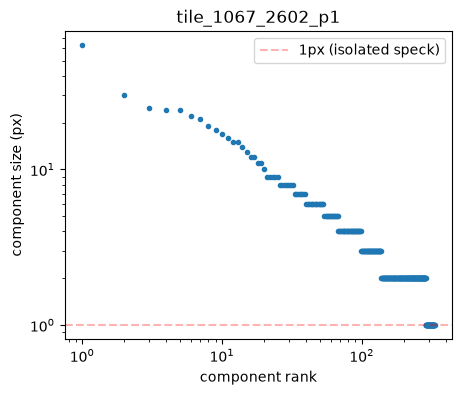

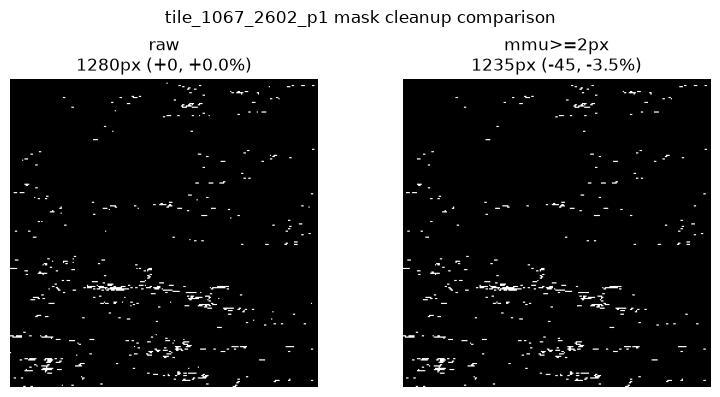

{'raw': array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]], shape=(256, 256)),
 'mmu>=2px': array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]], shape=(256, 256))}

In [11]:
gain_conf, _, _ = read(
    tile_dir / "labels" / "gain_confidence.tif",
    bands=[1],
)
gain_conf = gain_conf[0]

gain_valid = ~np.isnan(gain_conf)
gain_binary = gain_valid

mask = np.asarray(gain_binary).astype(bool)
sizes = plot_size_distribution(mask, title=TILE_ID)
compare_cleanup_methods(mask, min_size=2, tile_id=TILE_ID)

,n,mean,median,std,min,q10,q25,q75,q90,max
removed,45.0,57.507625,54.509804,8.295930,50.196079,50.901959,52.549019,58.823528,68.862747,83.529411
retained,1235.0,60.888148,58.039215,9.364934,50.196079,51.372547,53.333332,66.274513,75.294121,89.803925


MMU < 2px: 45 pixels removed (3.52%)
Mean confidence difference: -3.3805
Median confidence difference: -3.5294


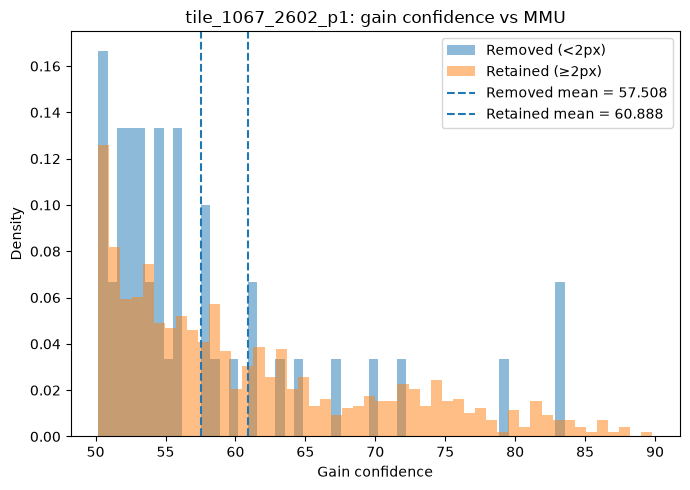

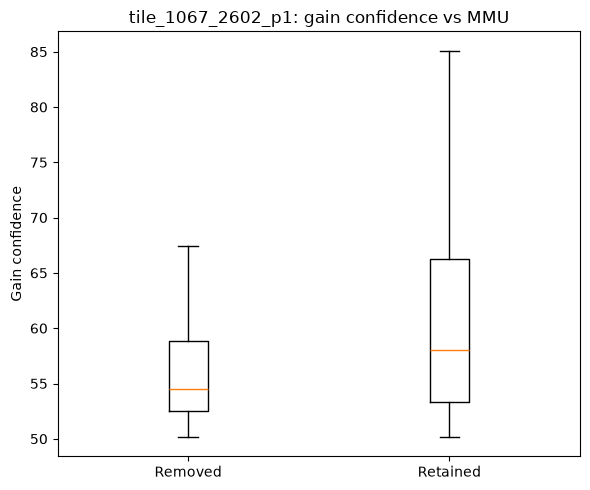

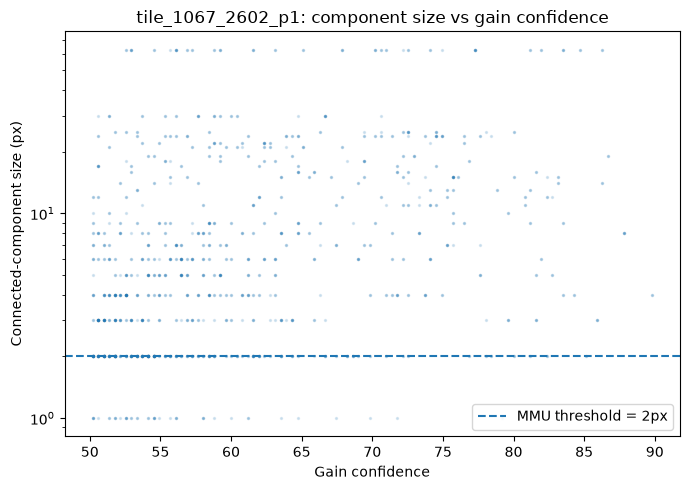

,min_size,removed_px,removed_pct,removed_mean,retained_mean,mean_difference,removed_median,retained_median,median_difference
0,2,45,3.515625,57.507625,60.888148,-3.380523,54.509804,58.039215,-3.529411
1,3,343,26.796875,57.312067,62.034863,-4.722796,54.509804,59.215687,-4.705883
2,4,460,35.937500,57.352941,62.685796,-5.332855,54.117645,59.607841,-5.490196
3,5,584,45.625000,57.753156,63.300090,-5.546934,54.509804,61.176472,-6.666668
4,10,888,69.375000,58.599629,65.684273,-7.084645,56.078430,64.705879,-8.627449


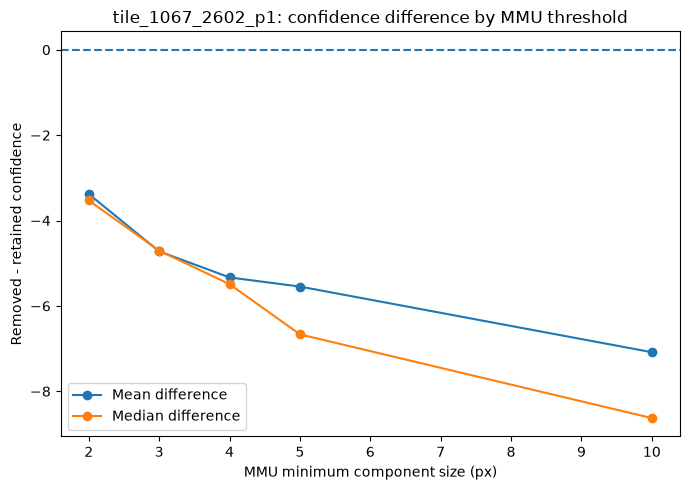

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage


mask = np.asarray(gain_binary).astype(bool)
confidence = np.asarray(gain_conf, dtype=float)

connectivity = 8
min_size = 2

structure = np.ones((3, 3), dtype=np.uint8)

labeled, n_components = ndimage.label(
    mask,
    structure=structure,
)

component_sizes = ndimage.sum(
    mask,
    labeled,
    index=np.arange(1, n_components + 1),
)

pixel_component_size = np.zeros_like(
    labeled,
    dtype=float,
)

valid_labels = labeled > 0

pixel_component_size[valid_labels] = (
    component_sizes[labeled[valid_labels] - 1]
)

valid_confidence = (
    mask
    & np.isfinite(confidence)
)

removed = (
    valid_confidence
    & (pixel_component_size < min_size)
)

retained = (
    valid_confidence
    & (pixel_component_size >= min_size)
)

removed_conf = confidence[removed]
retained_conf = confidence[retained]


def describe(values):
    return {
        "n": len(values),
        "mean": np.mean(values),
        "median": np.median(values),
        "std": np.std(values),
        "min": np.min(values),
        "q10": np.percentile(values, 10),
        "q25": np.percentile(values, 25),
        "q75": np.percentile(values, 75),
        "q90": np.percentile(values, 90),
        "max": np.max(values),
    }


summary = pd.DataFrame({
    "removed": describe(removed_conf),
    "retained": describe(retained_conf),
}).T

display(summary)

print(
    f"MMU < {min_size}px: "
    f"{len(removed_conf):,} pixels removed "
    f"({100 * len(removed_conf) / valid_confidence.sum():.2f}%)"
)

print(
    f"Mean confidence difference: "
    f"{removed_conf.mean() - retained_conf.mean():.4f}"
)

print(
    f"Median confidence difference: "
    f"{np.median(removed_conf) - np.median(retained_conf):.4f}"
)


fig, ax = plt.subplots(figsize=(7, 5))

ax.hist(
    removed_conf,
    bins=50,
    density=True,
    alpha=0.5,
    label=f"Removed (<{min_size}px)",
)

ax.hist(
    retained_conf,
    bins=50,
    density=True,
    alpha=0.5,
    label=f"Retained (≥{min_size}px)",
)

ax.axvline(
    removed_conf.mean(),
    linestyle="--",
    label=f"Removed mean = {removed_conf.mean():.3f}",
)

ax.axvline(
    retained_conf.mean(),
    linestyle="--",
    label=f"Retained mean = {retained_conf.mean():.3f}",
)

ax.set_xlabel("Gain confidence")
ax.set_ylabel("Density")
ax.set_title(f"{TILE_ID}: gain confidence vs MMU")
ax.legend()

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(6, 5))

ax.boxplot(
    [removed_conf, retained_conf],
    tick_labels=["Removed", "Retained"],
    showfliers=False,
)

ax.set_ylabel("Gain confidence")
ax.set_title(f"{TILE_ID}: gain confidence vs MMU")

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(7, 5))

valid = valid_confidence

ax.scatter(
    confidence[valid],
    pixel_component_size[valid],
    s=2,
    alpha=0.15,
)

ax.axhline(
    min_size,
    linestyle="--",
    label=f"MMU threshold = {min_size}px",
)

ax.set_yscale("log")
ax.set_xlabel("Gain confidence")
ax.set_ylabel("Connected-component size (px)")
ax.set_title(
    f"{TILE_ID}: component size vs gain confidence"
)
ax.legend()

plt.tight_layout()
plt.show()


thresholds = [2, 3, 4, 5, 10]

rows = []
total = valid_confidence.sum()

for threshold in thresholds:
    removed = (
        valid_confidence
        & (pixel_component_size < threshold)
    )

    retained = (
        valid_confidence
        & (pixel_component_size >= threshold)
    )

    r = confidence[removed]
    k = confidence[retained]

    rows.append({
        "min_size": threshold,
        "removed_px": len(r),
        "removed_pct": 100 * len(r) / total,
        "removed_mean": r.mean(),
        "retained_mean": k.mean(),
        "mean_difference": r.mean() - k.mean(),
        "removed_median": np.median(r),
        "retained_median": np.median(k),
        "median_difference": (
            np.median(r) - np.median(k)
        ),
    })

mmu_results = pd.DataFrame(rows)

display(mmu_results)


fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    mmu_results["min_size"],
    mmu_results["mean_difference"],
    marker="o",
    label="Mean difference",
)

ax.plot(
    mmu_results["min_size"],
    mmu_results["median_difference"],
    marker="o",
    label="Median difference",
)

ax.axhline(0, linestyle="--")

ax.set_xlabel("MMU minimum component size (px)")
ax.set_ylabel("Removed - retained confidence")
ax.set_title(
    f"{TILE_ID}: confidence difference by MMU threshold"
)
ax.legend()

plt.tight_layout()
plt.show()

In [1]:
import ee
from export import composites
from config import settings

#    "ireland_west_galway", -9.0524, 53.2707,
#    "ireland_east_dublin", -6.2603, 53.3498,
#    "northern_spain_coruna", -8.409, 43.362,
#    "central_germany_cologne", 6.9603, 50.9375,
#    "southern_italy_naples", 14.2681, 40.8518,


TILE_LON, TILE_LAT = -9.0524, 53.2707  # swap for whichever tile you want to inspect
YEAR = 2017 # most cloud affected year

geom = ee.Geometry.Point(TILE_LON, TILE_LAT).buffer(2000).bounds()
cs_thresh = settings.cloud_score_thresh

median_img = composites.s2_composite(geom, YEAR)  # production method

# mean variant, reusing the same masked collection
start, end = f"{YEAR}-01-01", f"{YEAR+1}-01-01"
ic = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterDate(start, end)
    .filterBounds(geom)
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 50))
)
ic = composites._join_cloud_score_plus(ic, geom, start, end)
masked = (
    ic.map(composites._mask_cloud_score_plus)
    .select(composites.NATIVE_10M_BANDS + composites.NATIVE_20M_BANDS)
    .map(composites._upsample_20m_bands_to_10m)
)
mean_img = masked.mean()

# quality mosaic variant, ranked by Cloud Score+ cs_cdf itself
def _with_quality(img):
    linked = composites._join_cloud_score_plus(
        ee.ImageCollection([img]), geom, start, end
    ).first()
    return img.addBands(linked.select(composites.CLOUD_SCORE_PLUS_BAND))

qm_img = masked.map(_with_quality).qualityMosaic(composites.CLOUD_SCORE_PLUS_BAND)

import geemap
Map = geemap.Map(center=[TILE_LAT, TILE_LON], zoom=13)

vis_rgb = {"bands": ["B4", "B3", "B2"], "min": 0, "max": 3000, "gamma": 1.2}

Map.addLayer(median_img, vis_rgb, "Median", True)
Map.addLayer(mean_img, vis_rgb, "Mean", False)
Map.addLayer(qm_img, vis_rgb, "Quality Mosaic (Cloud Score+)", False)

# per-method missing-pixel overlay, same pattern used earlier in this conversation
for name, img in (("Median", median_img), ("Mean", mean_img), ("Quality Mosaic", qm_img)):
    missing = img.mask().reduce(ee.Reducer.min()).Not()
    Map.addLayer(missing.selfMask(), {"palette": ["FF0000"]}, f"Missing - {name}", False)

Map

EEException: Earth Engine client library not initialized. See http://goo.gle/ee-auth.